In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import FancyBboxPatch
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "statistic" else NOTEBOOK_DIR
LOG_ROOT = PROJECT_ROOT / "logs"
LOG2_ROOT = PROJECT_ROOT / "logs2"

VARIANT = 0
TOTAL_EPISODES = 10_000
VALIDATION_TAG = "Reward/validation"
TRAIN_TAG = "Reward/train"
TRAIN_SMOOTHING_WINDOW = 100

RUNS = [
    {
        "name": "DQN",
        "version": "DQN v1.11",
        "path": LOG_ROOT / "DQN_v1.11_variant_0",
        "color": "tab:blue",
    },
    {
        "name": "Dueling DQN",
        "version": "DQN v4.7",
        "path": LOG_ROOT / "DQN_v4.7_variant_0",
        "color": "tab:orange",
    },
    {
        "name": "Double Dueling DQN",
        "version": "DQN v5.1.2",
        "path": LOG2_ROOT / "DQN_v5.1.2_variant_0",
        "color": "tab:green",
    },
]


def read_scalar_series(run_path: Path, tag: str, max_step: int | None = None):
    if not run_path.exists():
        raise FileNotFoundError(f"Missing TensorBoard log directory: {run_path}")

    event_files = list(run_path.glob("events.out.tfevents*"))
    if not event_files:
        raise FileNotFoundError(f"No TensorBoard event file found in: {run_path}")

    accumulator = EventAccumulator(str(run_path), size_guidance={"scalars": 0})
    accumulator.Reload()

    scalar_tags = accumulator.Tags().get("scalars", [])
    if tag not in scalar_tags:
        raise KeyError(f"Tag {tag!r} not found in {run_path}. Available scalar tags: {scalar_tags}")

    series = [(point.step, point.value) for point in accumulator.Scalars(tag)]
    if max_step is not None:
        series = [(step, value) for step, value in series if step <= max_step]

    if not series:
        raise ValueError(f"No scalar points left after filtering {tag!r} to step <= {max_step}")

    return series


def smooth_series(series, window: int | None = None):
    if window is None or window <= 1:
        return series
    df = pd.DataFrame(series, columns=["episode", "value"])
    df["value"] = df["value"].rolling(window=window, min_periods=1).mean()
    return list(df.itertuples(index=False, name=None))


def load_curves(runs, tag: str, total_episodes: int | None = None, smoothing_window: int | None = None):
    curves = []
    missing_runs = []

    for run in runs:
        try:
            series = read_scalar_series(run["path"], tag=tag, max_step=total_episodes)
            series = smooth_series(series, smoothing_window)
        except Exception as exc:
            missing_runs.append((run["name"], run["path"], exc))
            continue

        best_step, best_value = max(series, key=lambda item: item[1])
        curves.append({**run, "series": series, "best_step": best_step, "best_value": best_value})

    return curves, missing_runs


def print_curve_summary(curves, missing_runs, metric_name: str):
    for curve in curves:
        print(
            f"{curve['version']} ({curve['name']}): {len(curve['series'])} points, "
            f"best {metric_name} = {curve['best_value']:.2f} at episode {curve['best_step']}"
        )

    if missing_runs:
        print("\nRuns not plotted:")
        for name, path, exc in missing_runs:
            print(f"- {name}: {path} ({exc})")


def plot_curves(
    curves,
    y_label: str,
    info_lines,
    total_episodes: int | None = None,
    axis_width: float = 8.0,
    right_panel_width: float = 4.8,
    left_margin_width: float = 1.25,
    panel_gap_width: float = 0.28,
    height: float = 5.6,
    best_legend_label: str = "Best Reward",
):
    if not curves:
        raise RuntimeError("No curves were loaded. Check RUNS and log roots above.")

    fig_width = left_margin_width + axis_width + panel_gap_width + right_panel_width
    fig = plt.figure(figsize=(fig_width, height), dpi=140)

    bottom_margin = 0.72
    top_margin = 0.22
    plot_height = height - bottom_margin - top_margin

    ax = fig.add_axes([
        left_margin_width / fig_width,
        bottom_margin / height,
        axis_width / fig_width,
        plot_height / height,
    ])
    legend_ax = fig.add_axes([
        (left_margin_width + axis_width + panel_gap_width) / fig_width,
        bottom_margin / height,
        right_panel_width / fig_width,
        plot_height / height,
    ])
    legend_ax.axis("off")

    for curve in curves:
        steps = [step for step, _ in curve["series"]]
        values = [value for _, value in curve["series"]]
        ax.plot(steps, values, color=curve["color"], linewidth=1.9)

    legend_x = 0.03
    legend_y = 0.98
    line_width = 0.09
    text_gap = 0.035
    line_gap = 0.070
    row_gap = 0.018
    legend_width = 0.98
    text_x = legend_x + line_width + text_gap

    name_labels = [curve["name"] for curve in curves]
    best_labels = [f"{best_legend_label} = {curve['best_value']:.2f}" for curve in curves]

    def text_width_in_legend_axes(text: str, fontsize: int = 10) -> float:
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        probe = legend_ax.text(
            0,
            0,
            text,
            transform=legend_ax.transAxes,
            fontsize=fontsize,
            alpha=0,
        )
        width = probe.get_window_extent(renderer=renderer).width
        axis_width_px = legend_ax.get_window_extent(renderer=renderer).width
        probe.remove()
        return width / axis_width_px

    best_x = text_x + max(text_width_in_legend_axes(label) for label in name_labels) + 0.055
    row_heights = [line_gap for _ in name_labels]
    legend_height = sum(row_heights) + row_gap * (len(curves) - 1) + 0.055
    legend_box = FancyBboxPatch(
        (0.0, legend_y - legend_height + 0.02),
        legend_width,
        legend_height,
        boxstyle="round,pad=0.012",
        facecolor="white",
        edgecolor="0.8",
        transform=legend_ax.transAxes,
        clip_on=False,
        zorder=10,
    )
    legend_ax.add_patch(legend_box)

    current_y = legend_y - 0.035
    for curve, name_label, best_label in zip(curves, name_labels, best_labels):
        legend_ax.plot(
            [legend_x, legend_x + line_width],
            [current_y, current_y],
            transform=legend_ax.transAxes,
            color=curve["color"],
            linewidth=2.8,
            clip_on=False,
            zorder=11,
        )
        legend_ax.text(
            text_x,
            current_y,
            name_label,
            transform=legend_ax.transAxes,
            ha="left",
            va="center",
            fontsize=10,
            zorder=11,
        )
        legend_ax.text(
            best_x,
            current_y,
            best_label,
            transform=legend_ax.transAxes,
            ha="left",
            va="center",
            fontsize=10,
            zorder=11,
        )
        current_y -= line_gap + row_gap

    info_y = legend_y - legend_height - 0.055
    for line_idx, info_line in enumerate(info_lines):
        legend_ax.text(
            legend_x,
            info_y - 0.085 * line_idx,
            info_line,
            transform=legend_ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
        )

    ax.set_xlabel("Training episode", labelpad=10)
    ax.set_ylabel(y_label, labelpad=12)
    if total_episodes is not None:
        ax.set_xlim(0, total_episodes)
        ax.set_xticks(range(0, total_episodes + 1, 1000))
    else:
        ax.set_xlim(left=0)
    ax.grid(axis="x", linestyle="--", alpha=0.28)
    ax.grid(axis="y", linestyle="-", alpha=0.18)

    return fig, ax


print(f"Project root: {PROJECT_ROOT}")
print(f"Log root: {LOG_ROOT}")
print(f"Log2 root: {LOG2_ROOT}")


Project root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team
Log root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team/logs
Log2 root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team/logs2


DQN v1.11 (DQN): 100 points, best validation reward = 200.13 at episode 10000
DQN v4.7 (Dueling DQN): 100 points, best validation reward = 210.10 at episode 8000
DQN v5.1.2 (Double Dueling DQN): 100 points, best validation reward = 205.85 at episode 9400


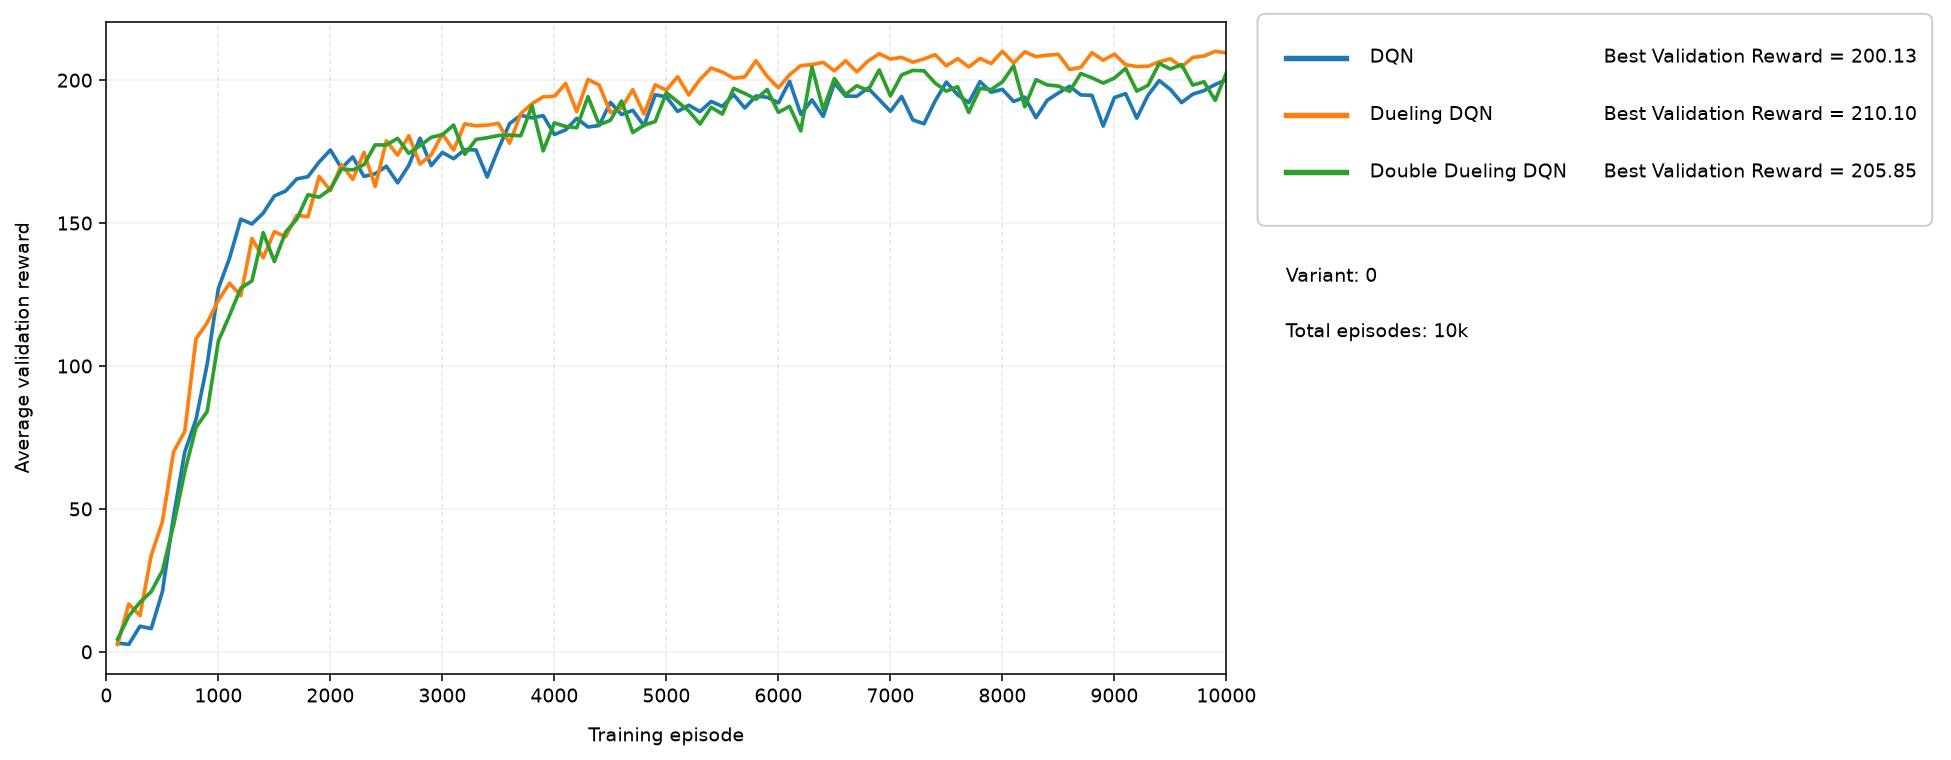

In [17]:
curves, missing_runs = load_curves(RUNS, tag=VALIDATION_TAG, total_episodes=TOTAL_EPISODES)
print_curve_summary(curves, missing_runs, metric_name="validation reward")
fig, ax = plot_curves(
    curves,
    y_label="Average validation reward",
    info_lines=[
        f"Variant: {VARIANT}",
        f"Total episodes: {TOTAL_EPISODES // 1000}k",
    ],
    total_episodes=TOTAL_EPISODES,
    best_legend_label="Best Validation Reward",
)
plt.show()


DQN v1.11 (DQN): 10000 points, best training reward (100-episode moving average) = 191.43 at episode 7506
DQN v4.7 (Dueling DQN): 10000 points, best training reward (100-episode moving average) = 201.24 at episode 9550
DQN v5.1.2 (Double Dueling DQN): 10000 points, best training reward (100-episode moving average) = 195.03 at episode 8468


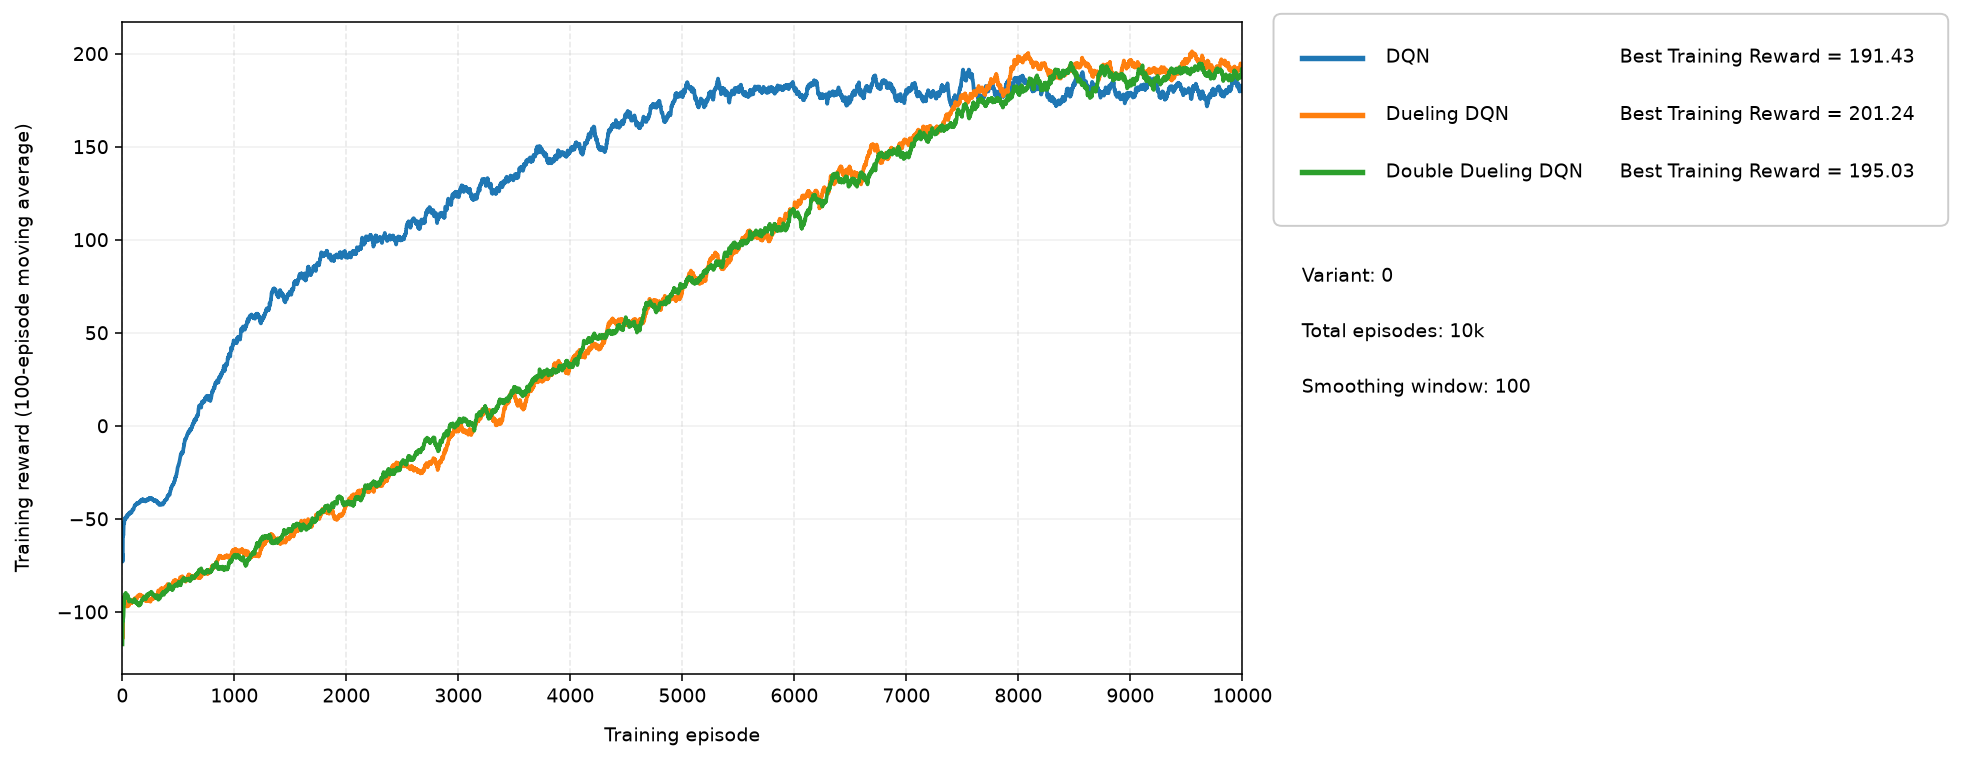

In [18]:
curves, missing_runs = load_curves(
    RUNS,
    tag=TRAIN_TAG,
    total_episodes=TOTAL_EPISODES,
    smoothing_window=TRAIN_SMOOTHING_WINDOW,
)
print_curve_summary(curves, missing_runs, metric_name=f"training reward ({TRAIN_SMOOTHING_WINDOW}-episode moving average)")
fig, ax = plot_curves(
    curves,
    y_label=f"Training reward ({TRAIN_SMOOTHING_WINDOW}-episode moving average)",
    info_lines=[
        f"Variant: {VARIANT}",
        f"Total episodes: {TOTAL_EPISODES // 1000}k",
        f"Smoothing window: {TRAIN_SMOOTHING_WINDOW}",
    ],
    total_episodes=TOTAL_EPISODES,
    best_legend_label="Best Training Reward",
)
plt.show()
